In [1]:
import re
import unicodedata
from pathlib import Path
import requests

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [3]:
DEVICE = torch.device("cpu")
print(DEVICE)

cpu


In [4]:
BATCH_SIZE = 64
SEQ_LEN = 100
STRIDE = SEQ_LEN  // 2

EMBED_SIZE = 128
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.2

LEARNING_RATE = 0.002
EPOCHS = 20

TEMPERATURE = 0.8

torch.manual_seed(42)


In [5]:
# "The Adventures of Sherlock Holmes" - Arthur Conan Doyle (Project Gutenberg)
URL = "https://www.gutenberg.org/files/1661/1661-0.txt"

DATA_PATH = Path("sherlock.txt")

if not DATA_PATH.exists():
    print("Downloading dataset...")
    response = requests.get(URL, timeout=30)
    response.raise_for_status()
    DATA_PATH.write_text(response.text, encoding="utf-8")

raw_text = DATA_PATH.read_text(encoding="utf-8-sig")

print("Raw characters:", len(raw_text))

Raw characters: 581424


In [6]:
def clean_gutenberg(raw):
    start = re.search(r"\*\*\* START OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*", raw, re.S)
    end = re.search(r"\*\*\* END OF THE PROJECT GUTENBERG EBOOK", raw, re.S)
    body = raw[start.end():end.start()].strip()

    # curly quotes, dashes and other unicode -> plain ascii
    replacements = {
        "\u201c": '"', "\u201d": '"',       # “ ”
        "\u2018": "'", "\u2019": "'",       # ‘ ’
        "\u2014": "--", "\u2013": "-",      # em dash, en dash
        "\u2026": "...", "\u00a0": " ",     # ellipsis, non-breaking space
        "\u00bd": "1/2", "\u00a3": " pounds ",
        "\u00e6": "ae", "\u00c6": "AE",
        "\u0153": "oe", "\u0152": "OE",
    }
    for old, new in replacements.items():
        body = body.replace(old, new)

    # strip accents: à -> a, é -> e
    body = unicodedata.normalize("NFKD", body)
    body = "".join(c for c in body if not unicodedata.combining(c))

    body = re.sub(r"[_*]", "", body)          # gutenberg italics markers
    body = re.sub(r"[ \t]+\n", "\n", body)    # trailing spaces
    body = re.sub(r"\n{3,}", "\n\n", body)     # collapse blank line runs

    return body


text = clean_gutenberg(raw_text)

print("Characters after cleaning:", len(text))
print("Removed:", len(raw_text) - len(text))


Characters after cleaning: 562454
Removed: 18970


In [7]:
print(text[:300])

The Adventures of Sherlock Holmes

by Arthur Conan Doyle

Contents

   I.     A Scandal in Bohemia
   II.    The Red-Headed League
   III.   A Case of Identity
   IV.    The Boscombe Valley Mystery
   V.     The Five Orange Pips
   VI.    The Man with the Twisted Lip
   VII.   The Adventure of the B


In [8]:
chars = sorted(set(text))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

print('vocab size: ', vocab_size)
print('Chars: ', "".join(chars))

vocab size:  77
Chars:  
 !"&'(),-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [9]:
def encode(s):
    return [stoi[c] for c in s]

def decode(indices):
    return "".join(itos[i] for i in indices)

print(encode('Holmes'))
print(decode(encode('Holmes')))

[32, 65, 62, 63, 55, 69]
Holmes


In [10]:
data = torch.tensor(encode(text), dtype=torch.long)

split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

print("Encoded data shape:", tuple(data.shape))
print("Train characters:", len(train_data))
print("Validation characters:", len(val_data))

Encoded data shape: (562454,)
Train characters: 506208
Validation characters: 56246


In [11]:
class CharDataset(Dataset):

    def __init__(self, data, seq_len, stride):
        self.data = data
        self.seq_len = seq_len
        self.stride = stride
        self.n_samples = (len(data) - seq_len - 1) // stride + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        start = idx * self.stride
        x = self.data[start:start + self.seq_len]
        y = self.data[start + 1:start + self.seq_len + 1]
        return x, y

In [12]:
train_dataset = CharDataset(train_data, SEQ_LEN, STRIDE)
val_dataset = CharDataset(val_data, SEQ_LEN, STRIDE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 158
Validation batches: 17


In [13]:
x_batch, y_batch = next(iter(train_loader))

print("x:", tuple(x_batch.shape))
print("y:", tuple(y_batch.shape))
print("\ninput :", repr(decode(x_batch[0, :40].tolist())))
print("target:", repr(decode(y_batch[0, :40].tolist())))

x: (64, 100)
y: (64, 100)

input : 'ined the seat of it with the\ngreatest at'
target: 'ned the seat of it with the\ngreatest att'


In [14]:
class CharGRU(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.gru = nn.GRU(
            input_size = embed_size, 
            hidden_size = hidden_size, 
            num_layers = num_layers, 
            batch_first = True, 
            dropout = dropout if num_layers > 1 else 0.0,
        )

        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden = None):
        x = self.embedding(x)
        output, hidden = self.gru(x, hidden)
        output = self.dropout(output)
        logits = self.fc(output)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device = device)
    

In [16]:
model = CharGRU(
    vocab_size = vocab_size, 
    embed_size = EMBED_SIZE, 
    hidden_size = HIDDEN_SIZE, 
    num_layers = NUM_LAYERS, 
    dropout = DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in  model.parameters())

print(model)
print('Number of params: ', total_params)

CharGRU(
  (embedding): Embedding(77, 128)
  (gru): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=77, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Number of params:  720845


In [17]:
# a GRU returns one hidden tensor - no cell state to unpack
with torch.no_grad():
    logits, h_n = model(x_batch[:4].to(DEVICE))

print("logits :", tuple(logits.shape))        # [batch, seq_len, vocab_size]
print("hidden :", tuple(h_n.shape))           # [num_layers, batch, hidden_size]

# recurrent weights only, to compare gate counts across the three notebooks
gru_recurrent = sum(p.numel() for n, p in model.named_parameters() if n.startswith("gru"))
print("\nGRU recurrent params:", gru_recurrent)
print("same-size LSTM would use:", round(gru_recurrent * 4 / 3), "(4 gates vs 3)")

logits : (4, 100, 77)
hidden : (2, 4, 256)

GRU recurrent params: 691200
same-size LSTM would use: 921600 (4 gates vs 3)


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

In [20]:
def train_one_epoch():
    model.train()
    total_loss = 0.0

    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)



In [21]:
@torch.no_grad()
def evaluate():
    model.eval()
    total_loss = 0.0

    for x, y in val_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

        total_loss += loss.item()

    return total_loss / len(val_loader)

In [23]:
checkpoint_path = "gru_sherlock.pt"

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch()
    val_loss = evaluate()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "stoi": stoi,
                "itos": itos,
                "vocab_size": vocab_size,
                "embed_size": EMBED_SIZE,
                "hidden_size": HIDDEN_SIZE,
                "num_layers": NUM_LAYERS,
                "dropout": DROPOUT,
                "epoch": epoch,
                "val_loss": val_loss,
            },
            checkpoint_path,
        )
        marker = "  <- best, saved"

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
        f"{marker}"
    )

print(f"\nBest validation loss {best_val_loss:.4f} at epoch {best_epoch}")
    

Epoch [01/20] | Train Loss: 1.6268 | Val Loss: 1.5111  <- best, saved
Epoch [02/20] | Train Loss: 1.4926 | Val Loss: 1.4397  <- best, saved
Epoch [03/20] | Train Loss: 1.4221 | Val Loss: 1.4043  <- best, saved
Epoch [04/20] | Train Loss: 1.3775 | Val Loss: 1.3828  <- best, saved
Epoch [05/20] | Train Loss: 1.3442 | Val Loss: 1.3776  <- best, saved
Epoch [06/20] | Train Loss: 1.3181 | Val Loss: 1.3672  <- best, saved
Epoch [07/20] | Train Loss: 1.2997 | Val Loss: 1.3607  <- best, saved
Epoch [08/20] | Train Loss: 1.2816 | Val Loss: 1.3542  <- best, saved
Epoch [09/20] | Train Loss: 1.2683 | Val Loss: 1.3592
Epoch [10/20] | Train Loss: 1.2558 | Val Loss: 1.3611
Epoch [11/20] | Train Loss: 1.2459 | Val Loss: 1.3629
Epoch [12/20] | Train Loss: 1.2367 | Val Loss: 1.3651
Epoch [13/20] | Train Loss: 1.2297 | Val Loss: 1.3616
Epoch [14/20] | Train Loss: 1.2227 | Val Loss: 1.3636
Epoch [15/20] | Train Loss: 1.2175 | Val Loss: 1.3617
Epoch [16/20] | Train Loss: 1.2113 | Val Loss: 1.3632
Epoch [1

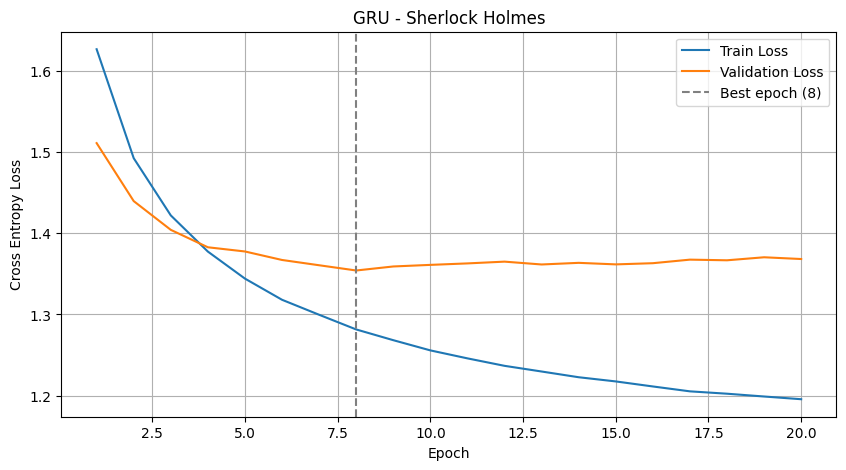

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("GRU - Sherlock Holmes")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# roll back to the best epoch before generating
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded epoch", checkpoint["epoch"], "with val loss", round(checkpoint["val_loss"], 4))

Loaded epoch 8 with val loss 1.3542


In [26]:
@torch.no_grad()
def generate_text(prompt, max_new_tokens=500, temperature=0.8):
    model.eval()

    input_ids = torch.tensor(
        encode(prompt), dtype=torch.long, device=DEVICE
    ).unsqueeze(0)   # [1, seq_len]

    hidden = model.init_hidden(batch_size=1, device=DEVICE)

    # warm the hidden state up on the prompt, then feed one character at a time
    if input_ids.shape[1] > 1:
        _, hidden = model(input_ids[:, :-1], hidden)

    current = input_ids[:, -1:]
    generated = prompt

    for _ in range(max_new_tokens):
        logits, hidden = model(current, hidden)

        logits = logits[:, -1, :] / temperature
        probabilities = F.softmax(logits, dim=-1)

        next_char = torch.multinomial(probabilities, num_samples=1)

        generated += itos[next_char.item()]
        current = next_char

    return generated

In [28]:
print(generate_text("Hello ", max_new_tokens=300, temperature=TEMPERATURE))

Hello to think of my friend, strucks an old stage. Do you do not have been done never come into the box, and there is a gapponed and gave a card cause of a poper-body. I had not a little point which I was a little in my prottored this grey loves, and the doubt that it would be the garden was
struck
sharp 


In [29]:
for temp in [0.5, 0.8, 1.2]:
    print(f"--- temperature = {temp} ---")
    print(generate_text("Holmes ", max_new_tokens=200, temperature=temp))
    print()

--- temperature = 0.5 ---
Holmes to be a hand of Mary Seependly glancing on the house."

"And all that I was a sign of the matter until the commentinged with the bank of the third of seven best that a dark and the and should be all t

--- temperature = 0.8 ---
Holmes at satistation."

"I was almost give his hands?"

"Never to such a man.

"It is an excuse to my going for you and the stone. On the man who had been a sidebothes and passed my arms.

"Sir. This was ve

--- temperature = 1.2 ---
Holmes as it. You sheI, loweling."

"Oh, reaping it as were yourself
back travelling your house in the speeve?"

He printed my swust a wife. "On her sitco clear
to see him in an Eynegs estate."

"Thank you a

